# Arabic Book Recommendation System

## Project Team
### Students
- Raghad Almutairi (رغد المطيري)
- Shooq Alqurashi (شوق القريشي)
- Haifa Alsudairi (هيفاء السديري)
- Batool Alfawzan (بتول الفوزان)
- Norah Alarifi (نوره العريفي)

**Academic Institution:** King Saud University

**Course:** SWE 485

**Semester:** 2025 Second Semester

## Project Overview
This project aims to develop a recommendation system for Arabic books using the Jamalon bookstore dataset.
The system will help users discover relevant books based on various attributes like genre, price, and content,
addressing the unique challenges of Arabic book discovery and classification.

## Project Motivation
### 1. Market Need
- Limited availability of sophisticated recommendation systems for Arabic books
- Growing demand for personalized book discovery in the Arabic literary market
- Need for better organization and accessibility of Arabic literary content

### 2. Technical Challenges
- Handling Arabic text processing and classification
- Managing bilingual content and mixed-language entries
- Dealing with unique Arabic publishing patterns and categorization

### 3. Cultural Impact
- Promoting Arabic literature and knowledge dissemination
- Supporting Arabic content digitization efforts
- Enhancing accessibility to Arabic literary resources

## Dataset Description
**Source:** Jamalon Online Bookstore  
**Size:** 8980 books

### Features
- Unique ID: A unique identifier for each book (Numerical).
- Title: The name of the book (Text).
- Author: The author's name (Text).
- Description: A brief description of the book (Text)
- Pages: The total number of pages in the book (Numerical)
- Publication Year: The year the book was published (Numerical)
- Publisher: The name of the publisher (Categorical).
- Cover: The cover type, such as Paperback or Hardcover (Categorical).
- Category: The main category of the book (e.g., Literature, Islamic Books) (Categorical).
- Subcategory: A more specific classification under each category (Categorical).
- Price: The price of the book (Numerical).

The Category and Subcategory columns act as classification labels, organizing books into different genres. These labels are useful for building the recommendation model based on user preferences.

---



Missing Values:
 Description    574
dtype: int64

Numeric Columns Summary:
             Price         Pages  Publication year
count  8986.000000   8986.000000       8986.000000
mean     51.504644    290.197196       1446.235366
std      62.425666    550.010609        902.201453
min       0.340000      0.000000          0.000000
25%      18.750000    144.000000          0.000000
50%      35.630000    232.000000       2006.000000
75%      56.250000    352.000000       2015.000000
max     937.560000  41520.000000       2020.000000


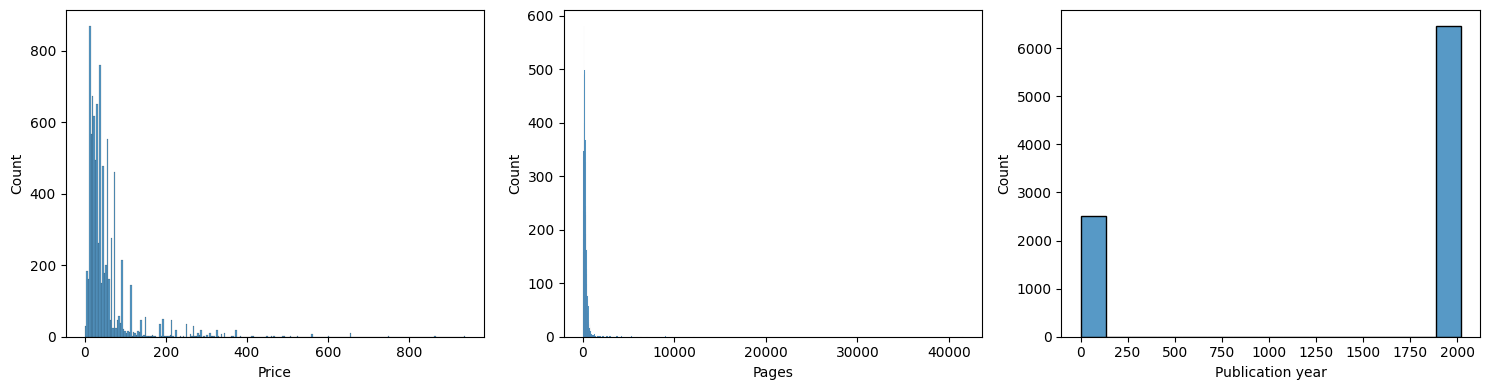

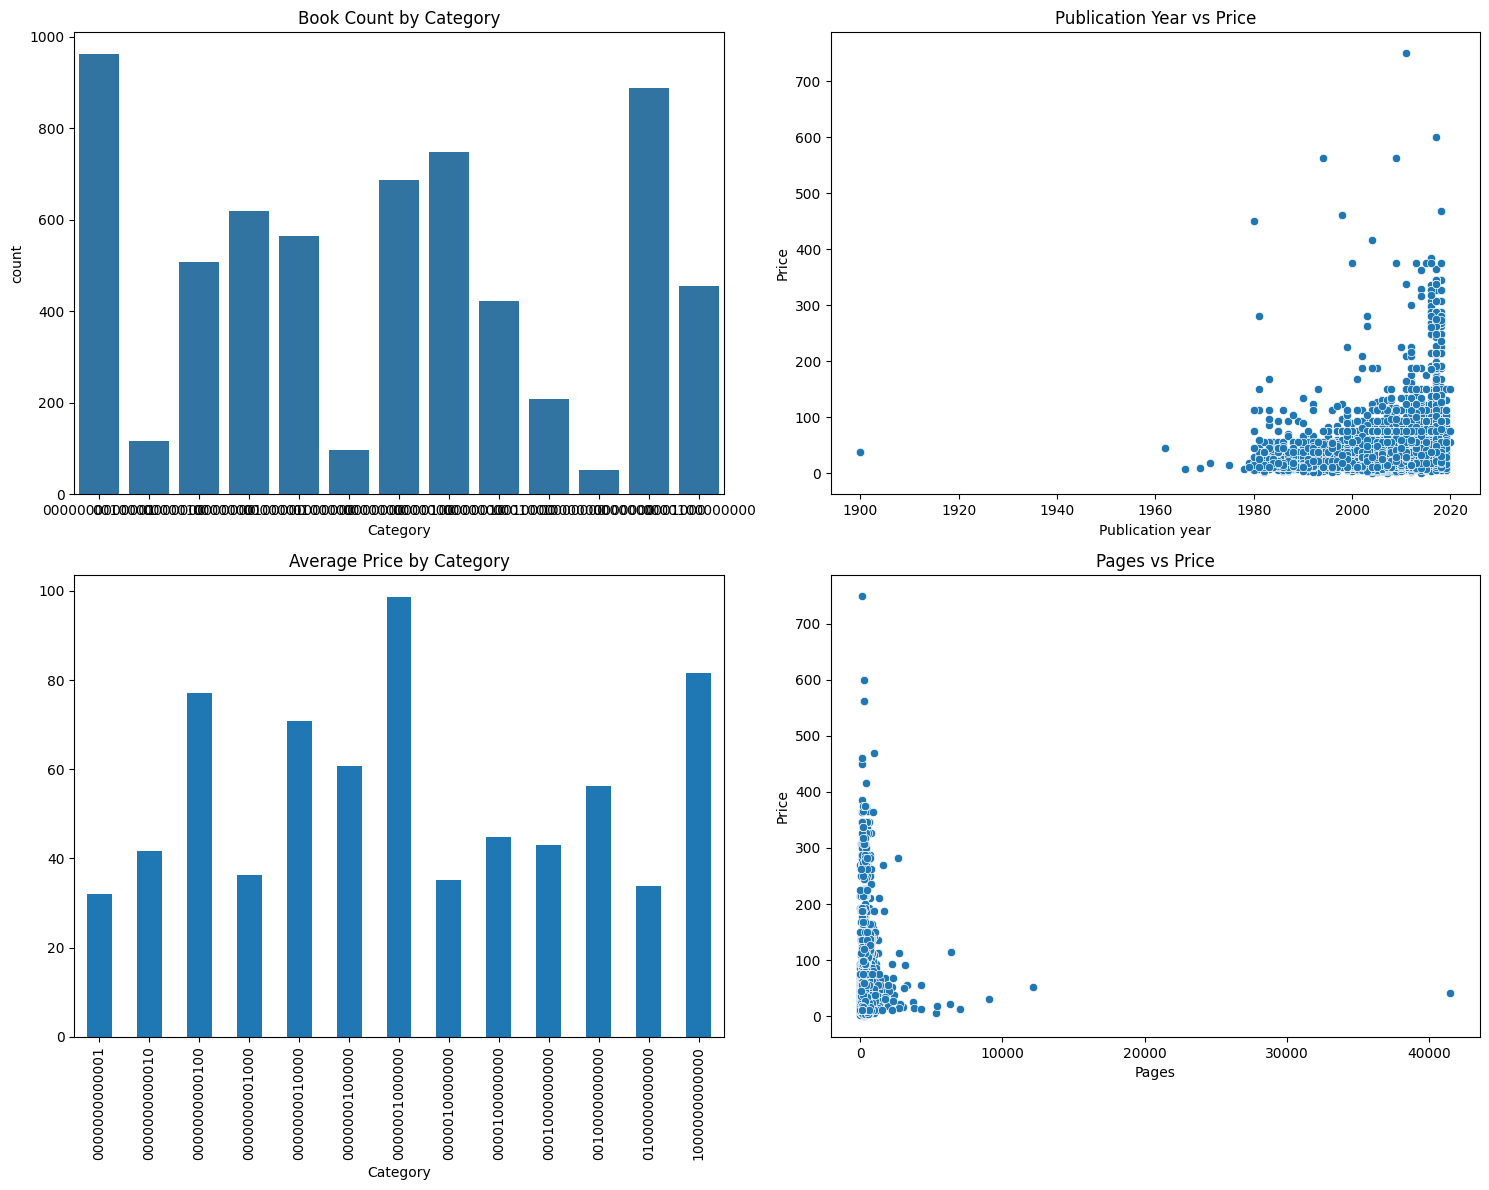

In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from langdetect import detect
import re
from sklearn.preprocessing import LabelEncoder

# 2. Load and Initial Inspection
df = pd.read_csv('/home/nouarif4/Downloads/jamalon dataset.csv')

# 3. Data Analysis
def analyze_data(df):
    # Display missing values
    missing_values = df.isnull().sum()
    print("\nMissing Values:\n", missing_values[missing_values > 0])
    
    # Basic statistics for numeric columns
    print("\nNumeric Columns Summary:")
    print(df.describe()[['Price', 'Pages', 'Publication year']])
    
    # Plot distributions
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, col in enumerate(["Price", "Pages", "Publication year"]):
        sns.histplot(data=df, x=col, ax=axes[i])
    plt.tight_layout()
    plt.show()

# 4. Data Cleaning Functions
def clean_arabic_text(text):
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', str(text))  # Remove diacritics
    text = re.sub(r"[!\"#\$%&'\(\)\*\+,\-./:;<=>?@\[\]\\^_`{|}~،؛؟«»]", '', text)  # Remove punctuation
    return re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces

def clean_dataset(df):
    clean_df = df.copy()
    
    # Remove unnecessary columns
    clean_df = clean_df.drop(columns=['Unnamed: 0', 'Cover'], errors='ignore')
    
    # Remove English titles
    clean_df = clean_df[~clean_df['Title'].apply(lambda x: bool(re.compile(r'[a-zA-Z]').search(str(x))))]
    
    # Clean text fields
    clean_df['Title'] = clean_df['Title'].apply(clean_arabic_text)
    clean_df['Description'] = clean_df['Description'].apply(clean_arabic_text)
    
    # Filter invalid data
    clean_df = clean_df[
        clean_df['Description'].notna() &
        clean_df['Author'].notna() &
        (clean_df['Publication year'].between(1800, 2024)) &
        (clean_df['Price'] >= 0)
    ]
    
    return clean_df

# 5. Category Mapping
category_map = {
    "الأدب والخيال": "0000000000001",
    "الكتب الإسلامية": "0000000000010",
    "الاقتصاد والأعمال": "0000000000100",
    "الفلسفة": "0000000001000",
    "الصحافة والإعلام": "0000000010000",
    "الكتب السياسية": "0000000100000",
    "العلوم والطبيعة": "0000001000000",
    "الأسرة والطفل": "0000010000000",
    "السير والمذكرات": "0000100000000",
    "الفنون": "0001000000000",
    "التاريخ والجغرافيا": "0010000000000",
    "الرياضة والتسلية": "0100000000000",
    "الشرع والقانون": "1000000000000"
}

# 6. Main Processing
def main():
    # Analyze original data
    analyze_data(df)
    
    # Clean data
    clean_df = clean_dataset(df)
    
    # Encode categorical variables
    le = LabelEncoder()
    for col in ['Author', 'Publisher', 'Subcategory']:
        clean_df[col] = le.fit_transform(clean_df[col].astype(str))
    
    # Map categories
    clean_df['Category'] = clean_df['Category'].map(category_map)
    
    # Save cleaned dataset
    clean_df.to_csv("~/Downloads/outputnotebook.csv", index=False, encoding='utf-8-sig')
    
    # Visualize relationships
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Book count by category
    sns.countplot(data=clean_df, x='Category', ax=axes[0,0])
    axes[0,0].set_title("Book Count by Category")
    
    # Year vs Price
    sns.scatterplot(data=clean_df, x='Publication year', y='Price', ax=axes[0,1])
    axes[0,1].set_title("Publication Year vs Price")
    
    # Average price by category
    clean_df.groupby('Category')['Price'].mean().plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title("Average Price by Category")
    
    # Price vs Pages correlation
    sns.scatterplot(data=clean_df, x='Pages', y='Price', ax=axes[1,1])
    axes[1,1].set_title("Pages vs Price")
    
    plt.tight_layout()
    plt.show()
    
    return clean_df

# Run the analysis
clean_df = main()